In [1]:
import pandas as pd
import numpy as np
from datatools import get_index_K, get_price, get_cyq, get_rzrq, get_moneyflow, get_technical
import lightgbm as lgb
import matplotlib.pyplot as plt
from cal_cne6_factor import calc_cne6_factors

### 取特征及样本

In [2]:
allstock = pd.read_csv('data/allstock.csv')
allstock_list = allstock[(allstock['list_date'] < 20260101) & ~allstock['ts_code'].str.contains('BJ') &((allstock['delist_date'] >= 20190101)|(allstock['delist_date'].isna()))].ts_code.tolist()
delist = allstock[(allstock['list_date'] < 20260101) & ~allstock['ts_code'].str.contains('BJ') &(allstock['delist_date'] >= 20190101)].ts_code.tolist()
start_date = '2019-01-01'
end_date = '2026-03-31'

In [3]:
all_sample = get_price(allstock_list, '2019-01-01', '2026-05-31',fields=['open', 'adj_factor'])
all_sample['20d_returns'] = all_sample.groupby('ts_code')['open'].shift(-20) / all_sample['open'] - 1
all_sample.rename(columns={'open':'next_open'}, inplace=True)
all_sample = all_sample.fillna(-0.9999999)
all_sample['trade_date'] = all_sample.groupby('ts_code')['trade_date'].shift(1)
all_sample = all_sample[all_sample.trade_date.between(start_date, end_date)]

In [6]:
bench = get_index_K(['000852.SH'], start_date='2019-01-01', end_date='2026-05-31', fields=['open'])
bench['bench_20d_return'] = bench['open'].shift(-20) / bench['open'] -1
bench['trade_date'] = bench['trade_date'].shift(1)

all_sample = all_sample.merge(bench[['trade_date', 'bench_20d_return']], on='trade_date', how='left')
all_sample['20d_excess_returns'] = all_sample['20d_returns'] - all_sample['bench_20d_return']
all_sample['Y_20d'] = all_sample.groupby('trade_date')['20d_excess_returns'].rank(pct=True)

In [9]:
all_sample.to_parquet('data/factor/all_sample.parquet', index=False)

In [20]:
factor1_de = calc_cne6_factors(delist, '2019-01-01', '2026-03-31')

cyq = get_cyq(delist, '2019-01-01', '2026-03-31')
rzrq = get_rzrq(delist, '2019-01-01', '2026-03-31')
monthflow = get_moneyflow(delist, '2019-01-01', '2026-03-31')

tech = get_technical(delist, '2019-01-01', '2026-03-31')

加载价格数据...
加载指数数据...
矩阵: 2019 交易日 × 221 只股票
计算 Daily std...
计算 Cumulative range...


c:\Users\User\Desktop\Quant\cal_cne6_factor.py:99: RuntimeWarning: All-NaN slice encountered
  factor_values = np.nanmax(window_rets, axis=0) - np.nanmin(window_rets, axis=0)


计算 Short Term reversal...
计算 Seasonality...
计算 Industry Momentum...
计算 BETA / Hist sigma / Historical alpha...
计算 Relative strength...
加载长期价格数据...
加载长期指数数据...
计算 Long term relative strength...
计算 Long term historical alpha...
加载基础数据...
加载财务数据...
加载TTM数据...
计算换手率因子...
计算市值因子...
计算估值/杠杆因子...
计算盈利能力...
计算财务质量因子...
计算应计项目...
计算投资质量...
加载分析师预测数据...
计算分析师预测因子...
组装结果...
done


In [ ]:
factor1_de = factor1_de[~factor1_de['ts_code'].isin(['300344.SZ', '300391.SZ', '600355.SH'])]
factor1 = pd.concat([factor1, factor1_de]).sort_values(['trade_date','ts_code'])
factor1.to_parquet('data/factor/cne6_factor.parquet', index=False)

In [ ]:
factor2_de = pd.merge(cyq, rzrq, on=['trade_date', 'ts_code'], how='outer').merge(monthflow, on=['trade_date', 'ts_code'], how='outer')
factor2_de = factor2_de[~factor2_de['ts_code'].isin(['300344.SZ', '300391.SZ', '600355.SH'])]
factor2 = pd.concat([factor2, factor2_de]).sort_values(['trade_date','ts_code'])
factor2.to_parquet('data/factor/other_factor.parquet', index=False)

In [ ]:
tech = tech[~tech['ts_code'].isin(['300344.SZ', '300391.SZ', '600355.SH'])]
factor3 = pd.concat([factor3, tech]).sort_values(['trade_date','ts_code'])
factor3.to_parquet('data/factor/tech_factor.parquet', index=False)

#### training

In [3]:
sample_train = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/sample_train.parquet')
sample_oot = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/sample_oot.parquet')

In [ ]:
lgb_params = {
    'objective': 'regression', # 虽然是Rank，但用regression配合分位数Y通常比lambdarank更稳定
    'metric': 'rmse',
    'learning_rate': 0.03,     # 学习率要低
    'max_depth': 4,            # 绝对不要超过5！金融数据浅层逻辑最稳
    'num_leaves': 10,          # 与max_depth匹配，限制复杂度
    'subsample': 0.7,          # 行采样（防共线性强的股票集群主导模型）
    'colsample_bytree': 0.6,   # 列采样（让150个因子都有机会参与，防某几个因子独占）
    'reg_alpha': 0.5,          # L1正则化
    'reg_lambda': 1.0,         # L2正则化
    'min_child_samples': 200,  # 叶子节点最小样本量（非常重要，防止模型去拟合极小众的极端妖股）
    'n_estimators': 1000,      # 设大一点，配合早停
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# 从 train_val_df 中切出 20% 作为验证集 (按时间切，比如22年全年)
val_df = sample_train[sample_train['trade_date'] >= '2022-05-01']
train_df = sample_train[sample_train['trade_date'] < '2022-05-01']
feature_cols = sample_train.columns[8:]
lgb_train = lgb.Dataset(train_df[feature_cols], train_df['Y_20d'])
lgb_val = lgb.Dataset(val_df[feature_cols], val_df['Y_20d'])

model = lgb.train(
    lgb_params,
    lgb_train,
    valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(100)])
# 在 OOT 集(23年+)上进行日频预测 对预测结果做截面标准化
sample_oot['predict_score'] = model.predict(sample_oot[feature_cols])
sample_oot['predict_score'] = sample_oot.groupby('trade_date')['predict_score'].transform(lambda x: (x - x.mean()) / x.std())
# 计算 OOT 期间的日度 Rank IC
daily_ic = sample_oot.groupby('trade_date').apply(lambda x: x['predict_score'].corr(x['Y_20d'], method='spearman'))
print(f"OOT 平均 Rank IC: {daily_ic.mean():.4f}")
print(f"OOT IC 胜率: {(daily_ic > 0).mean():.2%}")

Training until validation scores don't improve for 10 rounds
[100]	valid_0's rmse: 0.28474
Early stopping, best iteration is:
[137]	valid_0's rmse: 0.284603
OOT 平均 Rank IC: 0.1199
OOT IC 胜率: 83.65%


In [7]:
feat_imp_df = pd.DataFrame({'feature': model.feature_name(), 'gain': model.feature_importance(importance_type='gain')})
feat_imp_df['gain'] /= feat_imp_df['gain'].sum()
feat_imp_df = feat_imp_df.sort_values(by='gain', ascending=False)
print("Top 10 Features by Gain:")
print(feat_imp_df.head(10))

Top 10 Features by Gain:
           feature      gain
12            stom  0.139175
6       hist_sigma  0.111884
61  sell_md_amount  0.088846
55   buy_sm_amount  0.043826
86       bias3_hfq  0.040609
0        daily_std  0.040167
47       cost_5pct  0.035926
41            adtp  0.032413
44       delta_cnt  0.031374
43       delta_eps  0.022514


In [14]:
sample_train['predict_score'] = model.predict(sample_train[feature_cols])
sample_train['predict_score'] = sample_train.groupby('trade_date')['predict_score'].transform(lambda x: (x - x.mean()) / x.std())

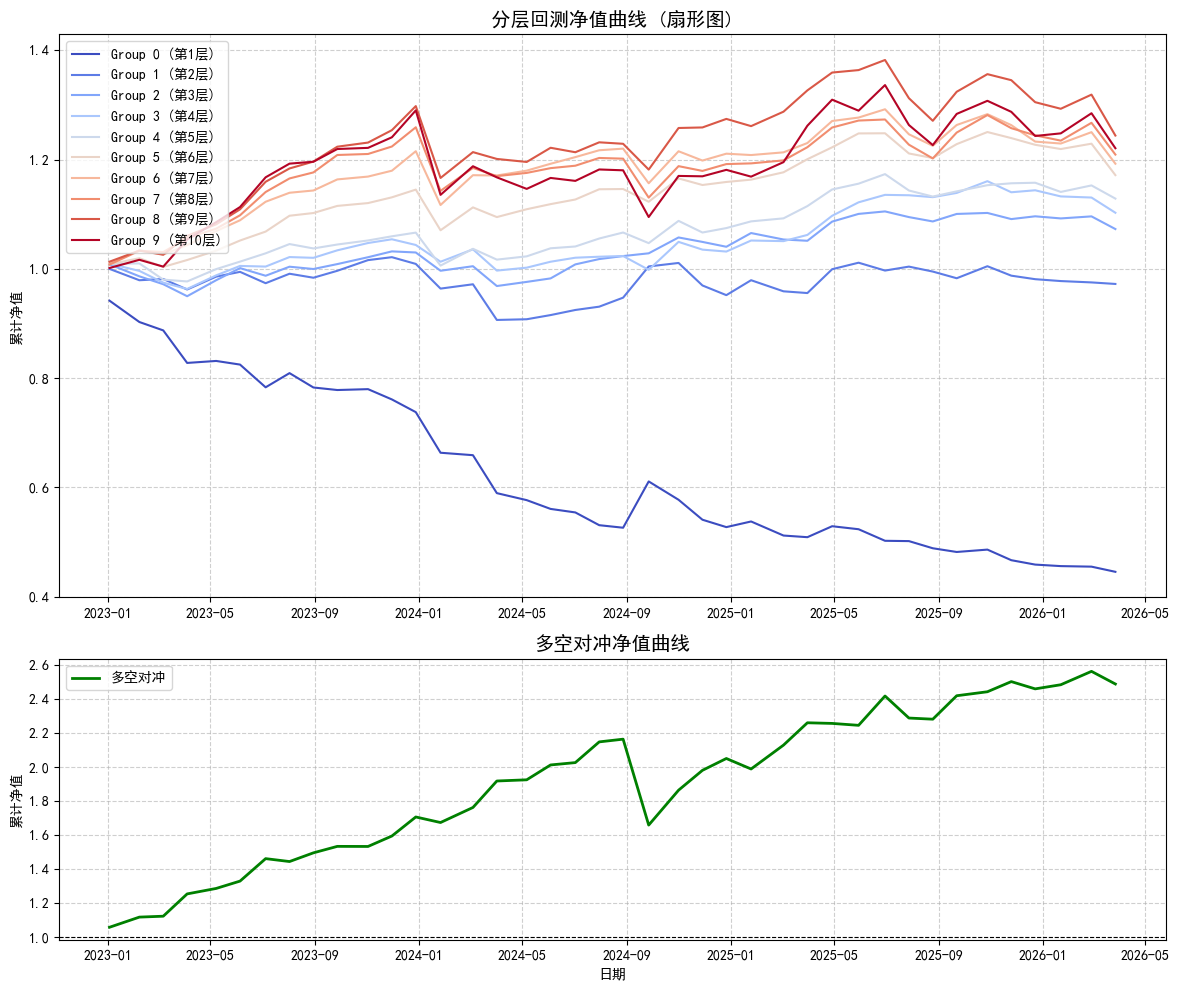

In [29]:
n=10
sample_oot['group'] = sample_oot.groupby('trade_date')['predict_score'].transform(
    lambda x: pd.qcut(x.rank(method='first'), n, labels=False, duplicates='drop'))
# 2. 计算每组每日的等权平均收益
# Group 0 是预测最差的组，Group n_groups-1 是预测最好的组
group_ret = sample_oot.groupby(['trade_date', 'group'])['20d_excess_returns'].mean().unstack()
#group_ret = group_ret[group_ret.index>='2021-01-01']
# 3. 处理换仓成本 (简化处理：假设每组每期全额换仓，扣除双边成本)
group_ret = group_ret - 2 * 0.0015
# 4. 计算多空对冲收益 (做多最好组，做空最差组)
group_ret['Long_Short'] = group_ret[n - 1] - group_ret[0]
# 5. 计算累计净值
group_nav = (1 + group_ret.iloc[::20]).cumprod()

# 绘图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})
# 子图1：各组净值曲线 (扇形图)
n_groups = len(group_nav.columns) - 1 # 减去 Long_Short 列
colors = plt.cm.coolwarm(np.linspace(0, 1, n_groups))
for i in range(0, n_groups, 1):
    axes[0].plot(group_nav.index, group_nav[i], label=f'Group {i} (第{i+1}层)', color=colors[i], linewidth=1.5)
axes[0].set_title('分层回测净值曲线 (扇形图)', fontsize=14)
axes[0].set_ylabel('累计净值')
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.6)
# 子图2：多空对冲净值曲线
axes[1].plot(group_nav.index, group_nav['Long_Short'], label='多空对冲', color='green', linewidth=2)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('多空对冲净值曲线', fontsize=14)
axes[1].set_xlabel('日期')
axes[1].set_ylabel('累计净值')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### step 4

In [ ]:
# ================= 1. 设定组合参数 =================
TOTAL_CAPITAL = 50000      # 总资金量（假设5万）
TOP_N = 8                  # 持仓数量（5-10只较合适）

def assign_weight_realistic(group):
    # 剔除买不起的（1手价格 > 单只预算）
    group = group[group['next_open'] <= (TOTAL_CAPITAL / TOP_N / 100)]
    top_n = group.nlargest(TOP_N, 'predict_score')
    top_n['lots'] = (TOTAL_CAPITAL / TOP_N / top_n['next_open']).apply(np.floor)
    top_n['weight'] = top_n['lots'] * top_n['next_open'] / TOTAL_CAPITAL
    return top_n[['ts_code', 'weight', 'lots']]
portfolio = sample_oot.groupby('trade_date').apply(assign_weight_realistic)
portfolio = portfolio.iloc[::20].reset_index(drop=True)

# 计算策略日收益
daily_pnl = portfolio.groupby('trade_date').apply(lambda x: np.sum(x['weight'] * x['20d_excess_returns'])).reset_index()
daily_pnl['net_return'] = daily_pnl['20d_excess_returns'] - 2 * 0.0015
daily_pnl['nav'] = (1 + daily_pnl['net_return']).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(daily_pnl['date'], daily_pnl['nav'], label='Strategy NAV', color='blue')
# 如果有基准（比如沪深300），也可以画上去
plt.title('OOT Backtest NAV Curve')
plt.xlabel('Date')
plt.ylabel('Net Asset Value')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
sample_oot[sample_oot.trade_date=='2026-03-02'].nlargest(10, 'predict_score')

NameError: name 'sample_oot' is not defined